In [1]:
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=True)

repository = scarf.cytebase.connect("scarf_docs")
ctrl_path = repository.download_dataset(
    name="kang_15K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
stim_path = repository.download_dataset(
    name="kang_14K_ifnb-pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)

ds_ctrl = scarf.DataStore(
    f"{ctrl_path}/data.zarr",
    nthreads=4,
    zarr_mode="r+",
)
ds_stim = scarf.DataStore(
    f"{stim_path}/data.zarr",
    nthreads=4,
    zarr_mode="r+",
)

Downloading bucket files: 40169307 / 40169307 complete

Downloading bytes: 40169307 / 40169307 complete

Downloading bucket files: 46151508 / 46151508 complete

Downloading bytes: 46151508 / 46151508 complete

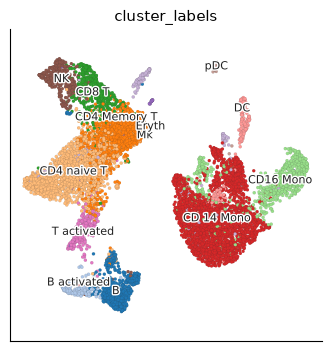

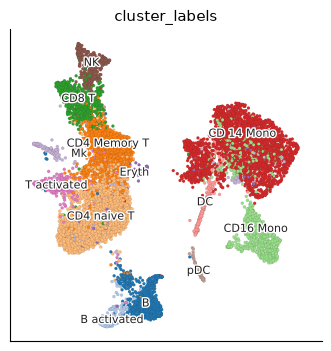

In [2]:
ds_ctrl.plots.embedding(
    layout_key="RNA_UMAP",
    color_by="cluster_labels",
)
ds_stim.plots.embedding(
    layout_key="RNA_UMAP",
    color_by="cluster_labels",
)

In [3]:
artifacts = ds_ctrl.pipeline.run(
    filtering=False,
    cell_cycle_scoring=False,
    highly_variable_features={
        "min_cells": 10,
        "top_n": 2000,
        "min_mean": -3,
        "max_mean": 2,
        "max_var": 6,
    },
    pca={"dims": 25},
    neighbors={"k": 17},
    umap=False,
    leiden={},
    paris=False,
    doublet_scoring=False,
    markers=False,
)
reference = ds_ctrl.build_mapping_reference(artifacts["neighbors"])

Identifying neighbors: 1 / 1 complete

Loading kmeans coordinates: 1 / 1 complete

In [4]:
mapping = ds_stim.run_mapping(
    reference,
    "stim",
    query_assay="RNA",
    save_k=5,
    missing_feature_policy="reference_mean",
)

In [5]:
peek = ds_stim.get_mapping_result(mapping, load_arrays=True)
peek.n_cells, int(peek.indices.shape[1]), peek.indices[:3], peek.distances[:3]

(10111,
 5,
 array([[2371,  672, 5685, 7681,  124],
        [7066, 6892, 7010,   69, 1989],
        [1619, 5304, 7642, 1039, 7848]], dtype=uint64),
 array([[ 7.5182128 ,  7.9602561 ,  8.89530277,  9.13731384,  9.31373215],
        [37.01360703, 37.27732849, 37.37385178, 37.58986282, 37.90789413],
        [ 7.11176968,  7.13337088,  7.24112892,  7.47884464,  7.50408363]]))

In [6]:
mapping.diagnostics

{'featureCoverage': 1.0,
 'queryBatchCount': 1,
 'algorithmVariant': 'scaled_pca',
 'zeroNormCellCount': 0,
 'queryScaledDispersion': 1.2273312252910447}

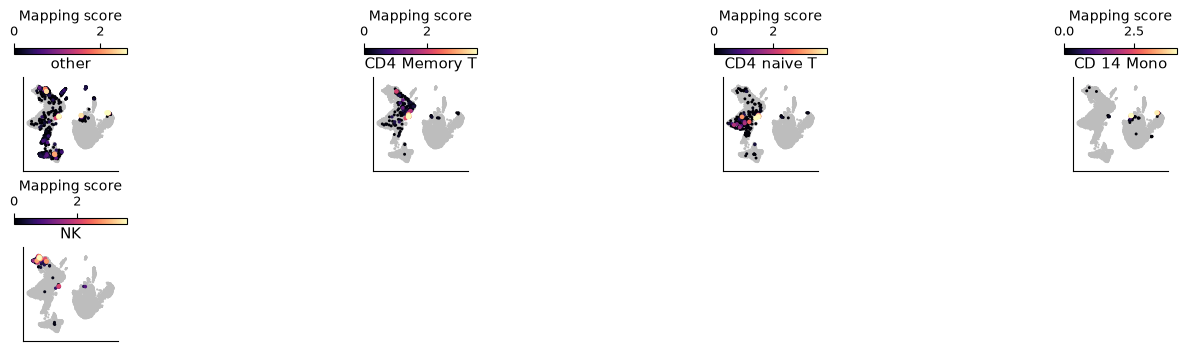

In [7]:
query_labels = np.asarray(ds_stim.cells.fetch("cluster_labels")).astype(str)
focus = {"CD 14 Mono", "CD4 Memory T", "CD4 naive T", "NK"}
score_groups = np.array(
    [label if label in focus else "other" for label in query_labels],
    dtype=object,
)
ds_stim.plots.mapping_score(
    mapping,
    layout_key="RNA_UMAP",
    target_groups=score_groups,
    size_by_score=True,
    figsize=(14, 3.4),
)

In [8]:
transferred_labels = ds_stim.get_target_classes(
    mapping,
    reference_class_group="cluster_labels",
    threshold_fraction=0.6,
)
ds_stim.cells.insert(
    "transferred_labels",
    transferred_labels.to_numpy(),
    overwrite=True,
)
accepted = transferred_labels.notna() & transferred_labels.ne("NA")
accepted.value_counts().rename(
    index={True: "accepted", False: "abstained"}
).rename("query cells")

accepted     8376
abstained    1735
Name: query cells, dtype: int64

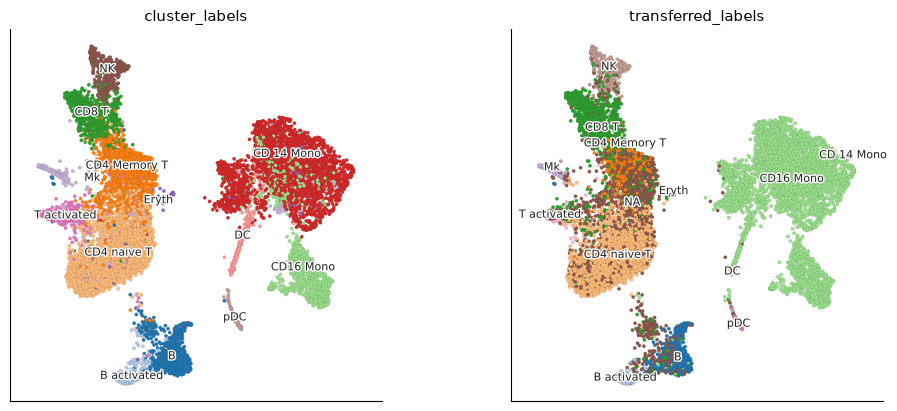

In [9]:
ds_stim.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=["cluster_labels", "transferred_labels"],
    figsize=(10, 4),
)

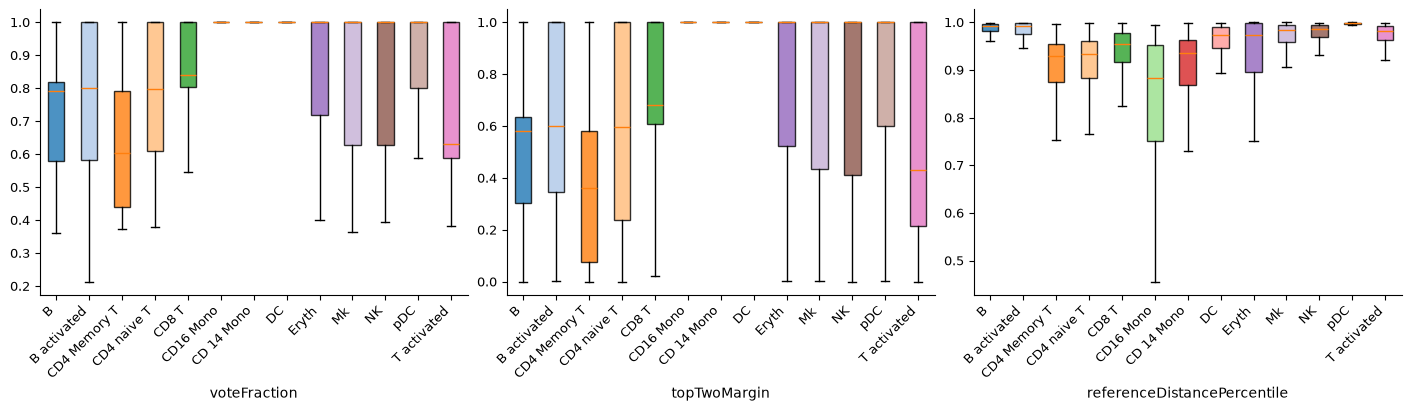

In [10]:
ds_stim.plots.mapping_evidence(
    mapping,
    reference_class_group="cluster_labels",
    target_groups=query_labels,
    metrics=("voteFraction", "topTwoMargin", "referenceDistancePercentile"),
    kind="box",
    threshold_fraction=0.6,
    figsize=(14, 4),
)

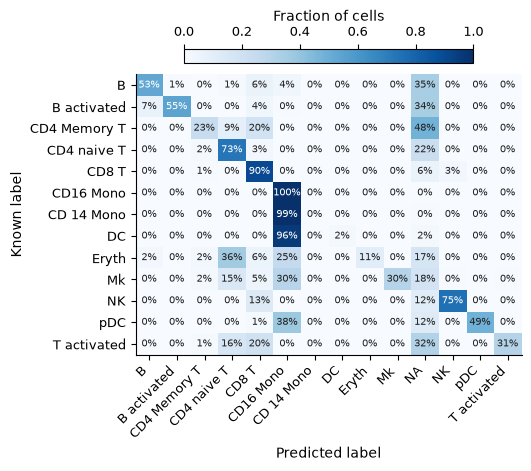

In [11]:
ds_stim.plots.mapping_confusion(
    mapping,
    reference_class_group="cluster_labels",
    known_labels=query_labels,
    normalize="true",
    threshold_fraction=0.6,
)

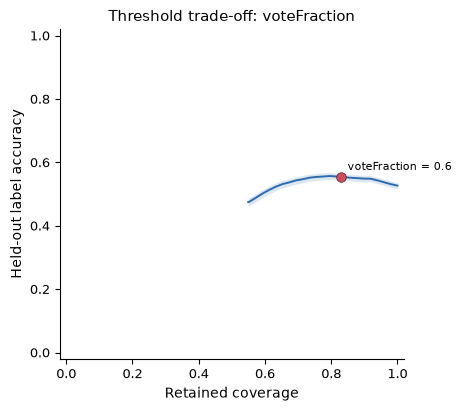

In [12]:
ds_stim.plots.mapping_calibration(
    mapping,
    reference_class_group="cluster_labels",
    known_labels=query_labels,
    chosen_threshold=0.6,
)

In [13]:
focus_labels = ("CD 14 Mono", "CD16 Mono", "NK")
focus_groups = np.array(
    [label if label in focus_labels else "other" for label in query_labels],
    dtype=object,
)
assert mapping.reference is not None
ref_classes = np.asarray(
    mapping.reference.fetch_cell_column("cluster_labels"),
    dtype=object,
)
score_mass: dict[str, pd.Series] = {}
for group, values in ds_stim.get_mapping_score(
    mapping,
    target_groups=focus_groups,
    log_transform=False,
):
    if group == "other":
        continue
    score_mass[str(group)] = (
        pd.Series(np.asarray(values, dtype=np.float64), index=ref_classes)
        .groupby(level=0, sort=False)
        .sum()
    )
score_mass_table = pd.DataFrame(
    {label: score_mass[label] for label in focus_labels if label in score_mass}
).fillna(0.0)
score_mass_table.loc[
    score_mass_table.max(axis=1).sort_values(ascending=False).index
].round(3)

,CD 14 Mono,CD16 Mono,NK
CD16 Mono,297.408,307.497,0.000
NK,0.044,0.000,216.549
CD8 T,0.486,0.000,58.158
CD4 naive T,0.136,0.000,6.304
CD 14 Mono,0.363,0.000,2.186
CD4 Memory T,0.000,0.000,0.907
B,0.000,0.000,0.267
Mk,0.000,0.000,0.250
pDC,0.000,0.000,0.000
T activated,0.000,0.000,0.000


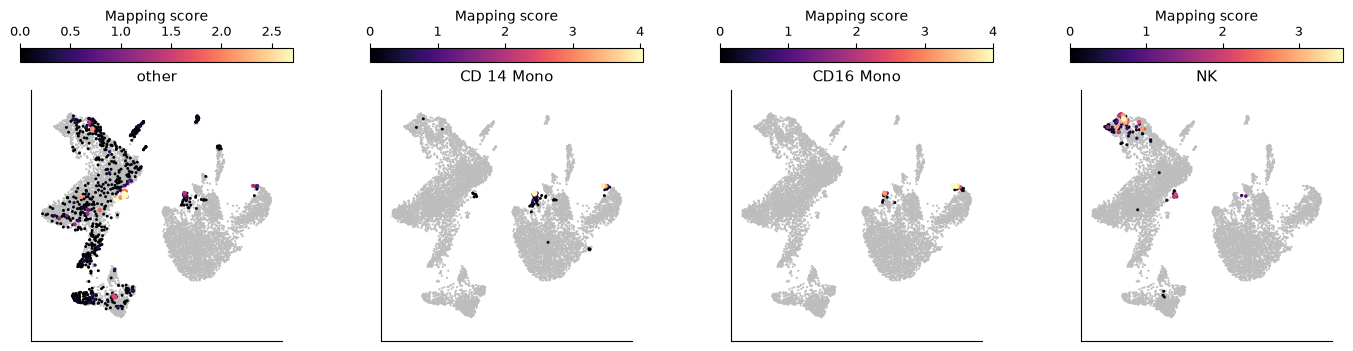

In [14]:
ds_stim.plots.mapping_score(
    mapping,
    layout_key="RNA_UMAP",
    target_groups=focus_groups,
    size_by_score=True,
    figsize=(14, 3.4),
)

In [15]:
reference = ds_ctrl.get_mapping_reference()
reloaded_mapping = ds_stim.get_mapping_result(
    "stim",
    reference=reference,
    query_assay="RNA",
)
reloaded_mapping.mapping_name, reloaded_mapping.n_cells

('stim', 10111)